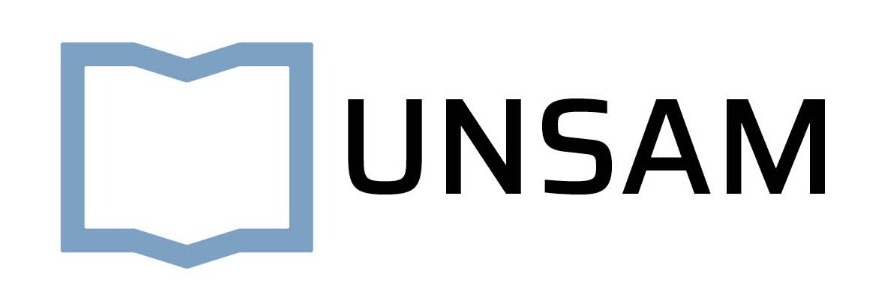

# APS : TS1 Castiñeira 

## Autor: Santiago Castiñeira


## Consigana del TP:
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de **$B$ bits** en un rango de $\pm V_F$ Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a **$f_S$ Hertz**.

Para ello se simulará el comportamiento del dispositivo al digitalizar una **senoidal contaminada con un nivel predeterminado de ruido.** Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- frecuencia $f_0$ arbitraria, por ejemplo:

$$
f_0 = \frac{f_S}{N} = \Delta f
$$

- **energía normalizada,** es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

- será de carácter aditivo, es decir la señal que entra al ADC será:

$$
s_R = s + n
$$

Siendo $n$ la secuencia que simula la interferencia, y $s$ la senoidal descrita anteriormente.

- La potencia del ruido será:

$$
P_n = k_n \cdot P_q \ \text{W}
$$

siendo el factor $k$ una escala para la potencia del ruido de cuantización:

$$
P_q = \frac{q^2}{12}
$$

- finalmente, $n$ será **incorrelado** y **Gaussiano**.

El ADC que deseamos simular trabajará a una frecuencia de muestreo:

$$
f_S = 1000 \ \text{Hz}
$$

y tendrá un rango analógico de:

$$
\pm V_F = 2 \ \text{Volts}
$$

Se pide:

**a)** Generar el siguiente resultado producto de la experimentación. $B = 4$ bits, $k_n = 1$.

**b)** Analizar para una de las siguientes configuraciones $B = \{4, 8 \text{ y } 16\}$ bits, $k_n = \{1/10, 1, 10\}$. Discutir los resultados respecto a lo obtenido en a).

## Introduccion:
En este trabajo se va a simular el funcionamiento de un ADC, teniendo en cuenta el muestreo, el ruido agregado a la señal y el efecto de la cuantización.

La idea es observar cómo estos factores modifican una señal senoidal tanto en el tiempo como en frecuencia.

### Punto a: generar los resultados producto de la experiencia B=4 bits Kn=1

En este primer punto se va a simular qué pasa cuando una señal senoidal con ruido entra a un ADC.

Primero se genera la senoide con los parámetros pedidos, después se le suma un ruido gaussiano y finalmente se cuantiza la señal usando un ADC de $4$ bits.

La idea es poder comparar la señal original, la señal que entra al ADC y la que obtenemos después de la cuantización.

Para este caso se toma:

$$
f_s = 1000\,\text{Hz}
$$

y:

$$
N = 1000
$$

por lo que la senoide tiene una frecuencia de $1\,\text{Hz}$.

También se ajusta su amplitud para que tenga potencia unitaria.

Con $B = 4$ bits se obtiene un paso de cuantización de:

$$
q = 0.125\,\text{V}
$$

y a partir de este valor se calcula la potencia del ruido que se agrega antes del ADC.

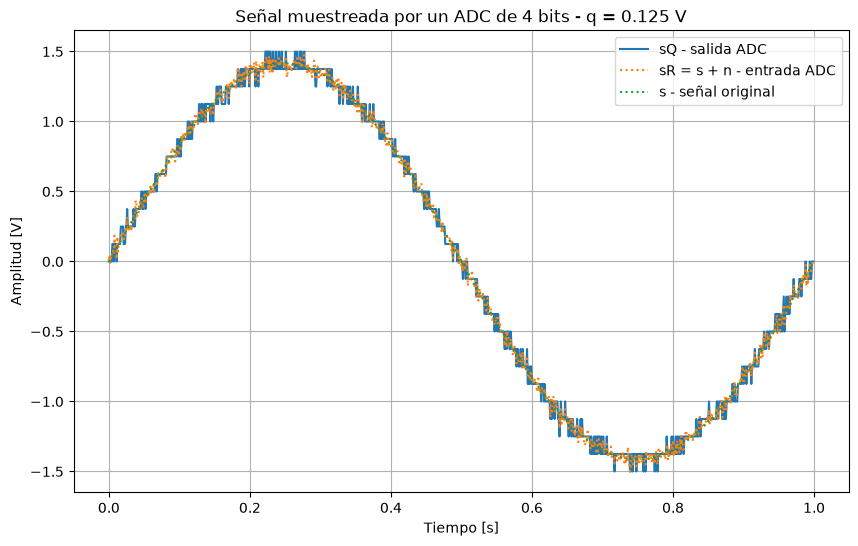

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#%% Variables y parametros:

fs = 1000        # frecuencia de muestreo [Hz]
N = 1000          # cantidad de muestras
f0 = fs / N        # frecuencia de la senoide [Hz]

A = np.sqrt(2)     # amplitud para varianza/potencia unitaria (como queremos varianza uniratia A= raiz de 2 )

B = 4              # bits del ADC
VF = 2            # valor usado por la consigna [V]
kn = 1         # relación entre ruido analógico y ruido de cuantización

ts = 1 / fs
tt = np.arange(N) * ts

#%% senoidal limpia

s = A * np.sin(2 * np.pi * f0 * tt)

#%% Paso de cuantización y potencia de cuantización

q = VF / (2**B)

Pq = q**2 / 12

#%% Ruido analógico gaussiano

Pn = kn * Pq
sigma_n = np.sqrt(Pn)

ruido = np.random.normal(0, sigma_n, N)

sR = s + ruido # señal que entra al ADC


#%% Cuantización

sQ = np.round(sR / q) * q

nq = sQ - sR # Error de cuantización

#%% Primer gráfico 

plt.figure(figsize=(10, 6))

plt.plot(tt, sQ, label='sQ - salida ADC')
plt.plot(tt, sR, ':', label='sR = s + n - entrada ADC')
plt.plot(tt, s, ':', label='s - señal original')

plt.title(f'Señal muestreada por un ADC de {B} bits - q = {q:.3f} V')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.legend()

plt.show()

En el gráfico se puede ver la senoide original, la misma señal después de agregarle ruido y finalmente la salida cuantizada del ADC.

El ruido genera pequeñas variaciones alrededor de la senoide, pero como su desvío estándar es bastante más chico que la amplitud de la señal, la forma senoidal se sigue distinguiendo bastante bien.

Por otro lado, la cuantización hace que la salida solo pueda tomar valores separados por pasos de $0.125\,\text{V}$.

Aun así, la salida del ADC sigue bastante bien la forma de la señal de entrada.

### segundo grafico
Ahora se analiza la señal en frecuencia para poder comparar la componente de la senoide con el ruido que se agregó antes del ADC y el ruido producido por la cuantización.

Para esto se utiliza la FFT y se representa la potencia de cada componente en dB.

Como la senoide tiene potencia unitaria, su componente principal se toma como referencia de $0\,\text{dB}$.

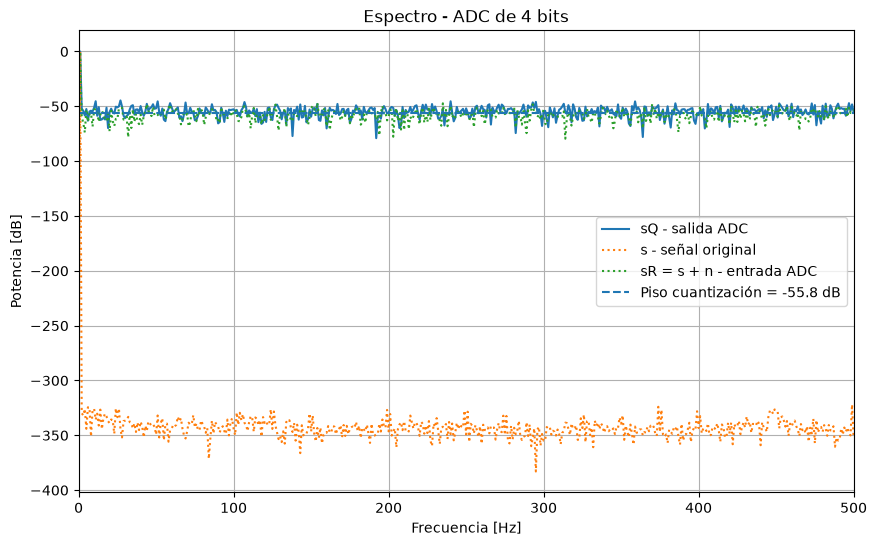

In [7]:
#%% Análisis en frecuencia

# FFT de cada señal
S = np.fft.rfft(s)        # FFT de la senoide original
SR = np.fft.rfft(sR)      #     de la señal con ruido antes del ADC
SQ = np.fft.rfft(sQ)      #     de la señal cuantizada

# Eje de frecuencias
ff = np.fft.rfftfreq(N, d=1/fs)   # frecuencias desde 0 Hz hasta fs/2

# Potencia unilateral de cada señal
Ps = 2 * (np.abs(S)**2) / N**2    # potencia de la senoide
PsR = 2 * (np.abs(SR)**2) / N**2  # potencia de la señal con ruido
PsQ = 2 * (np.abs(SQ)**2) / N**2  # potencia de la señal cuantizada

# Conversión de potencia a dB
Ps_dB = 10 * np.log10(Ps )     # senoide en dB
PsR_dB = 10 * np.log10(PsR )   # señal con ruido en dB
PsQ_dB = 10 * np.log10(PsQ )   # señal cuantizada en dB

# Piso teórico del ruido de cuantización:
# representa el nivel promedio de potencia que aporta la cuantización
# y sirve para compararlo con el ruido que aparece en el espectro.
eta_q = 2 * Pq / fs
eta_q_dB = 10 * np.log10(eta_q)

#%% Gráfico del espectro

plt.figure(figsize=(10,6))

plt.plot(ff, PsQ_dB, label='sQ - salida ADC')             # salida cuantizada
plt.plot(ff, Ps_dB, ':', label='s - señal original')      # senoide original
plt.plot(ff, PsR_dB, ':', label='sR = s + n - entrada ADC') # señal con ruido

plt.axhline(eta_q_dB,
            linestyle='--',
            label=f'Piso cuantización = {eta_q_dB:.1f} dB') # esto se lo pedi a chat es la linea reprecentacion de la linea de piso teorico.


plt.title(f'Espectro - ADC de {B} bits')   # título
plt.xlabel('Frecuencia [Hz]')              # eje x
plt.ylabel('Potencia [dB]')                # eje y
plt.grid(True)                              # grilla
plt.legend()                                # referencias
plt.xlim(0, fs/2)                           # mostramos de 0 a Nyquist
plt.show()

En este gráfico se observa el espectro completo de las tres señales hasta $500\,\text{Hz}$, que corresponde a la frecuencia de Nyquist.

Se puede ver un pico principal cerca de $1\,\text{Hz}$, correspondiente a la frecuencia de la senoide.

En cambio, las señales que contienen ruido presentan componentes distribuidas a lo largo de todo el espectro, formando un piso de ruido aproximadamente alrededor de los $-50$ a $-60\,\text{dB}$.

Además, se agregó una línea horizontal que indica el nivel teórico del ruido de cuantización, para poder compararlo con el piso de ruido obtenido en la simulación.

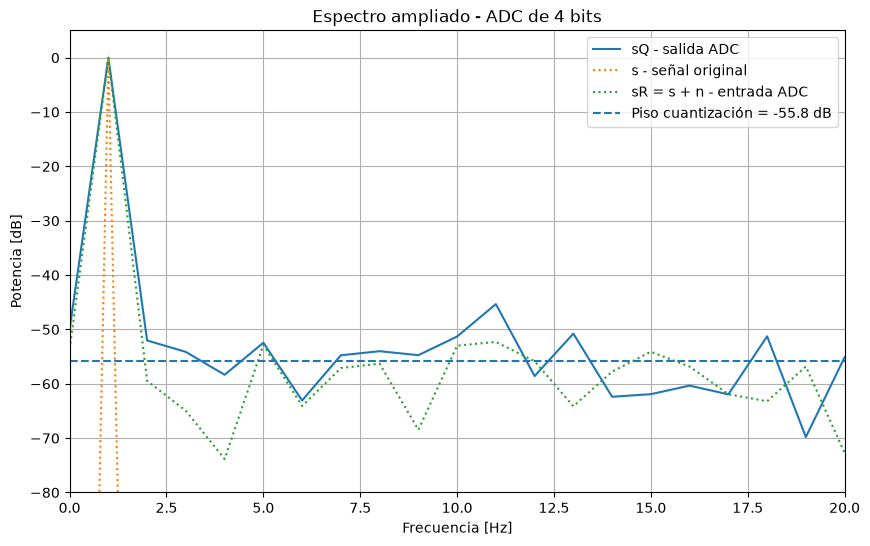

In [8]:
#%% Zoom del espectro en bajas frecuencias

plt.figure(figsize=(10,6))

plt.plot(ff, PsQ_dB, label='sQ - salida ADC')
plt.plot(ff, Ps_dB, ':', label='s - señal original')
plt.plot(ff, PsR_dB, ':', label='sR = s + n - entrada ADC')

plt.axhline(eta_q_dB,
            linestyle='--',
            label=f'Piso cuantización = {eta_q_dB:.1f} dB')

plt.title(f'Espectro ampliado - ADC de {B} bits')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid(True)
plt.legend()

plt.xlim(0, 20)     # zoom en bajas frecuencias de 0 a 20 Hz
plt.ylim(-80, 5)    # de -80 a 5 Hz

plt.show()

Para ver con más detalle la componente principal le hice zoom en las bajas frecuencias.

En este gráfico se distingue mejor el pico en $1\,\text{Hz}$, que llega aproximadamente a $0\,\text{dB}$ debido a que la senoide tiene potencia unitaria.

También se observa que fuera de esa frecuencia la señal original prácticamente no tiene contenido, mientras que la entrada y la salida del ADC mantienen un piso debido al ruido.

### histograma del error de cuantizacion:

Por último, se analiza el error producido por la cuantización.

Para esto se calcula la diferencia entre la señal que sale del ADC y la señal que entró al cuantizador.

Luego se realiza un histograma para observar cómo se distribuyen esos errores.

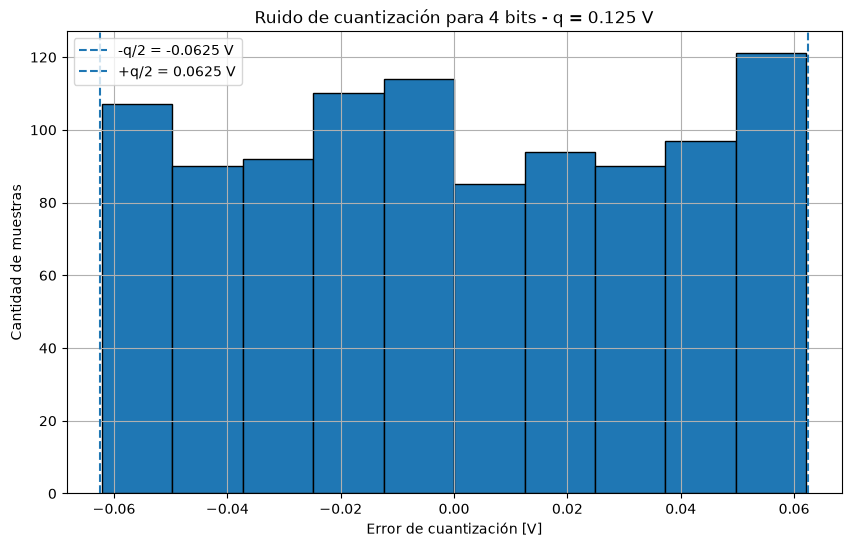

In [9]:
#%% Histograma del error de cuantización

plt.figure(figsize=(10,6))

plt.hist(nq, bins=10, edgecolor='black')   # distribución del error

# Límites teóricos del error: -q/2 y +q/2
plt.axvline(-q/2, linestyle='--',
            label=f'-q/2 = {-q/2:.4f} V')

plt.axvline(q/2, linestyle='--',
            label=f'+q/2 = {q/2:.4f} V')

plt.title(f'Ruido de cuantización para {B} bits - q = {q:.3f} V')
plt.xlabel('Error de cuantización [V]')
plt.ylabel('Cantidad de muestras')
plt.grid(True)
plt.legend()

plt.show()

En el histograma se observa que el error de cuantización queda limitado aproximadamente entre $-q/2$ y $+q/2$, es decir entre $-0.0625\,\text{V}$ y $0.0625\,\text{V}$.

También se puede ver que las muestras se reparten de manera bastante uniforme dentro de ese intervalo.

Como se utilizaron 1000 muestras y 10 grupos ( para tener aprox 100 muestras por blouqe), aunque aparecen pequeñas variaciones debido a que se trata de una simulación.

## Punto b: 
Analizar para una de las siguientes configuraciones $B = \{4, 8 \text{ y } 16\}$ bits, $k_n = \{1/10, 1, 10\}$. Discutir los resultados respecto a lo obtenido en a).

En este punto se van a probar distintas combinaciones de cantidad de bits y de $k_n$, para ver cómo cambia el comportamiento del ADC.

Al aumentar la cantidad de bits, el paso de cuantización $q$ se hace más chico y por lo tanto debería disminuir el ruido de cuantización.

Por otro lado, el valor de $k_n$ indica qué tan grande es el ruido agregado con respecto al ruido de cuantización: con $k_n = 0.1$ el ruido agregado es menor, con $k_n = 1$ ambos tienen la misma potencia y con $k_n = 10$ el ruido agregado es mayor.

La idea es comparar estos casos para ver qué efecto tiene cada parámetro sobre la señal.

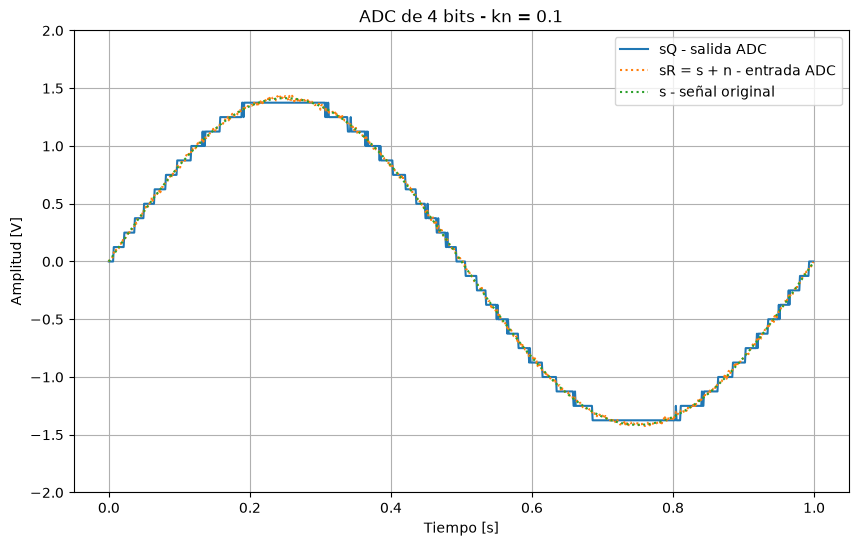

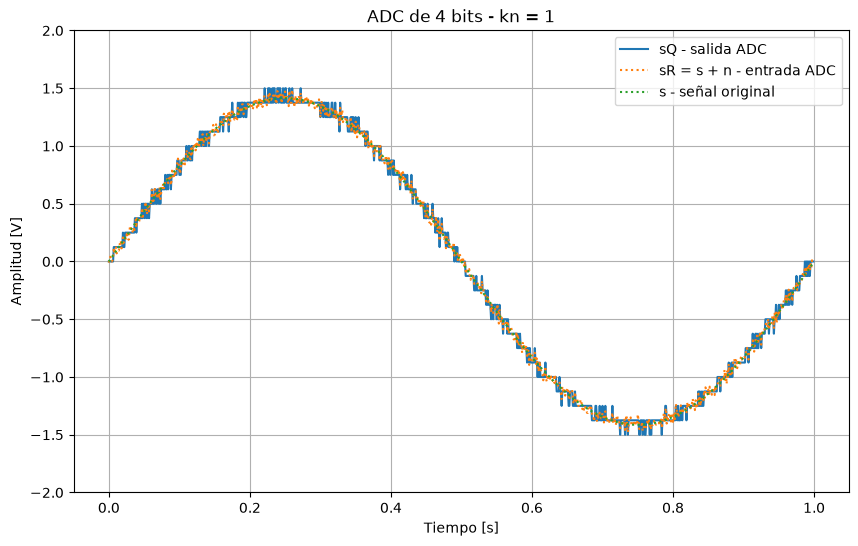

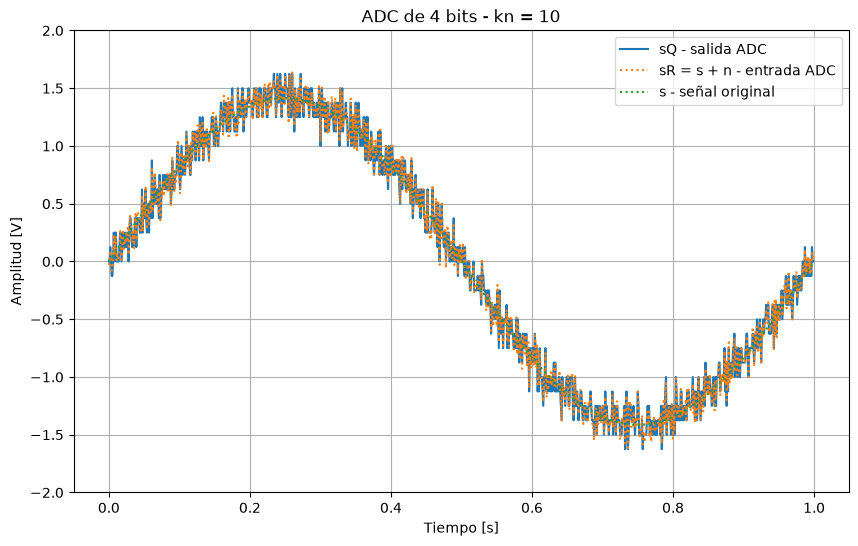

In [11]:
#%% Comparación para B = 4 bits y distintos valores de kn

B = 4
kn_valores = [0.1, 1, 10]

# Paso y potencia de cuantización
q = VF / (2**B)              # paso de cuantización
Pq = q**2 / 12               # potencia del ruido de cuantización

# Generamos un mismo ruido normalizado para comparar los tres casos
ruido_base = np.random.normal(0, 1, N)

# Guardamos los resultados para usarlos después
resultados_4bits = {}

for kn in kn_valores: # este siclo for ejecuta el mismo comando para los 3 valores para no hacer 3 veces esta aprte.

    Pn = kn * Pq                  # potencia del ruido agregado
    sigma_n = np.sqrt(Pn)         # desvío estándar del ruido

    ruido = sigma_n * ruido_base  # mismo ruido, cambiando su amplitud

    sR = s + ruido                # señal que entra al ADC
    sQ = np.round(sR / q) * q     # señal cuantizada

    # Guardamos los datos
    resultados_4bits[kn] = {
        'sR': sR,
        'sQ': sQ,
        'Pn': Pn,
        'sigma': sigma_n
    }

    # Gráfico temporal
    plt.figure(figsize=(10,6))

    plt.plot(tt, sQ, label='sQ - salida ADC')
    plt.plot(tt, sR, ':', label='sR = s + n - entrada ADC')
    plt.plot(tt, s, ':', label='s - señal original')

    plt.title(f'ADC de 4 bits - kn = {kn}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.ylim(-2, 2)                # misma escala para comparar los tres casos
    plt.grid(True)
    plt.legend()

    plt.show()

Luego se comparan los espectros para los tres valores de $k_n$, manteniendo el ADC en $4$ bits.

Como el paso de cuantización no cambia, el piso teórico asociado a la cuantización se mantiene igual.

En cambio, al aumentar $k_n$ aumenta la potencia del ruido agregado, por lo que se espera que su piso de ruido también aumente.

Para $4$ bits, el piso teórico de cuantización es aproximadamente $-55.8\,\text{dB}$.

Como:

$$
P_n = k_n P_q
$$

los valores esperados para el ruido agregado son:

| $k_n$ | Piso de cuantización | Piso del ruido agregado |
|---|---|---|
| $0.1$ | $-55.8\,\text{dB}$ | $-65.8\,\text{dB}$ |
| $1$ | $-55.8\,\text{dB}$ | $-55.8\,\text{dB}$ |
| $10$ | $-55.8\,\text{dB}$ | $-45.8\,\text{dB}$ |

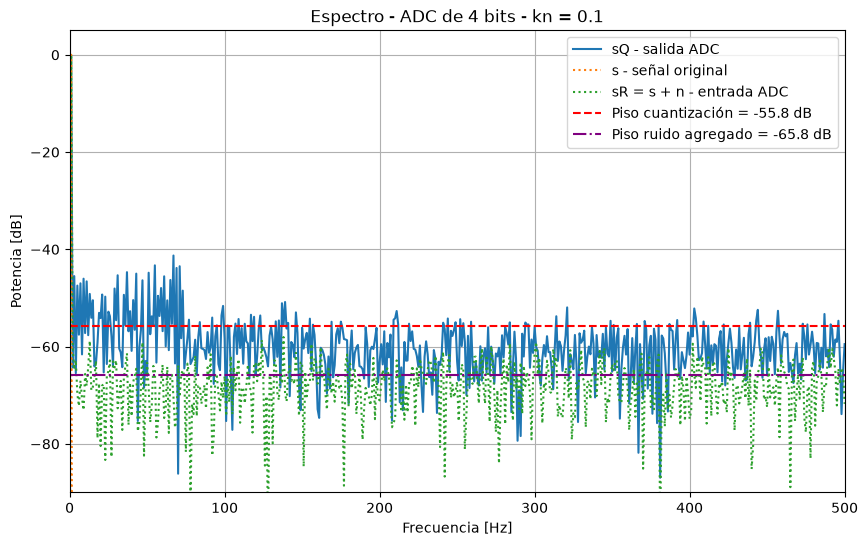

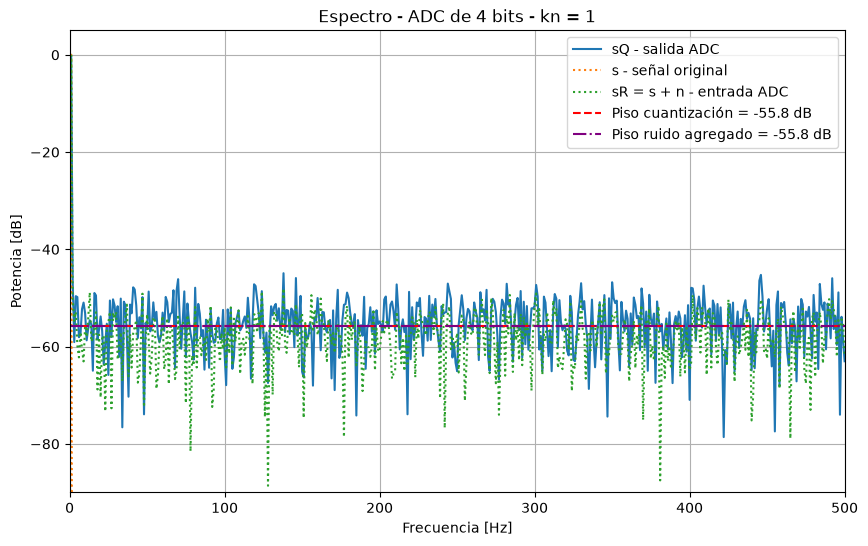

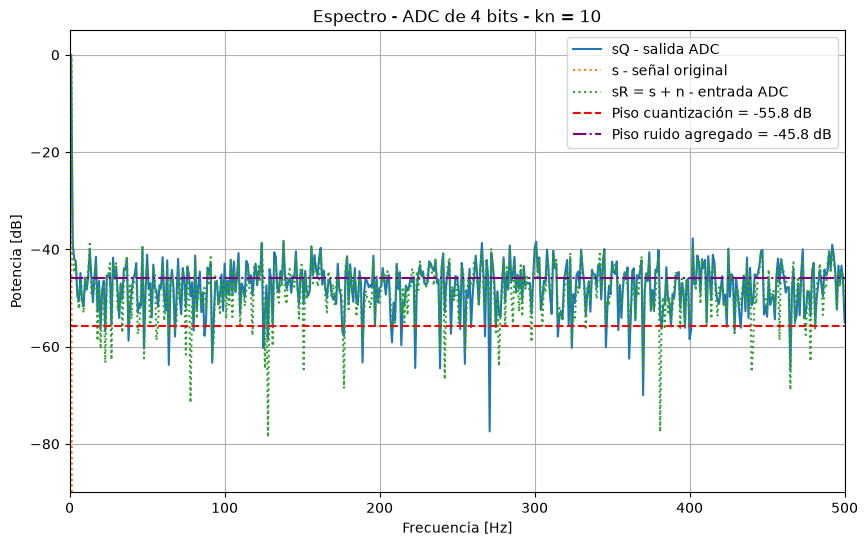

In [13]:
    #%% Espectros para B = 4 bits y distintos valores de kn

# Piso teórico de cuantización (es el mismo para los tres casos)
eta_q = 2 * Pq / fs
eta_q_dB = 10 * np.log10(eta_q)

for kn in kn_valores:

    # Recuperamos las señales que ya generamos
    sR = resultados_4bits[kn]['sR']     # entrada del ADC
    sQ = resultados_4bits[kn]['sQ']     # salida del ADC
    Pn = resultados_4bits[kn]['Pn']     # potencia del ruido agregado

    # FFT de las señales
    S = np.fft.rfft(s)                   # senoide original
    SR = np.fft.rfft(sR)                 # senoide + ruido
    SQ = np.fft.rfft(sQ)                 # salida cuantizada

    # Eje de frecuencias
    ff = np.fft.rfftfreq(N, d=1/fs)

    # Potencia unilateral
    Ps = 2 * (np.abs(S)**2) / N**2
    PsR = 2 * (np.abs(SR)**2) / N**2
    PsQ = 2 * (np.abs(SQ)**2) / N**2

    # Evitamos log10(0)
    eps = 1e-20

    # Potencia en dB
    Ps_dB = 10 * np.log10(Ps + eps)
    PsR_dB = 10 * np.log10(PsR + eps)
    PsQ_dB = 10 * np.log10(PsQ + eps)

    # Piso teórico del ruido agregado
    eta_n = 2 * Pn / fs
    eta_n_dB = 10 * np.log10(eta_n)

 #%% Gráfico
    plt.figure(figsize=(10,6))

    plt.plot(ff, PsQ_dB, label='sQ - salida ADC')
    plt.plot(ff, Ps_dB, ':', label='s - señal original')
    plt.plot(ff, PsR_dB, ':', label='sR = s + n - entrada ADC')

   # Piso de cuantización
    plt.axhline(eta_q_dB,
            color='red',
            linestyle='--',
            label=f'Piso cuantización = {eta_q_dB:.1f} dB')

   # Piso del ruido agregado
    plt.axhline(eta_n_dB,
            color='purple',
            linestyle='-.',
            label=f'Piso ruido agregado = {eta_n_dB:.1f} dB')
    
    plt.title(f'Espectro - ADC de 4 bits - kn = {kn}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [dB]')
    plt.grid(True)
    plt.legend()

    plt.xlim(0, fs/2)    # espectro completo
    plt.ylim(-90, 5)     # misma escala en los tres gráficos

    plt.show()

De esta forma se espera que, al aumentar $k_n$, el piso correspondiente al ruido agregado vaya subiendo, mientras que el piso de cuantización se mantenga en el mismo valor.

En los espectros se puede ver más claramente el efecto de cambiar $k_n$.

Como se mantienen los $4$ bits, el piso teórico del ruido de cuantización permanece en aproximadamente $-55.8\,\text{dB}$.

En cambio, el piso correspondiente al ruido agregado aumenta al aumentar $k_n$.

Para $k_n = 0.1$ queda por debajo del ruido de cuantización, con $k_n = 1$ ambos tienen aproximadamente la misma potencia y con $k_n = 10$ el ruido agregado pasa a ser el efecto dominante.

Esto también se refleja en la salida del ADC, cuyo piso de ruido aumenta a medida que aumenta $k_n$.

Ahora se repite la comparación utilizando un ADC de $8$ bits.

En este caso el paso de cuantización es mucho menor que con $4$ bits, por lo que se espera que la salida del ADC siga con mayor precisión a la señal de entrada.

Se mantienen los mismos valores de $k_n$ para poder comparar el efecto del ruido agregado.

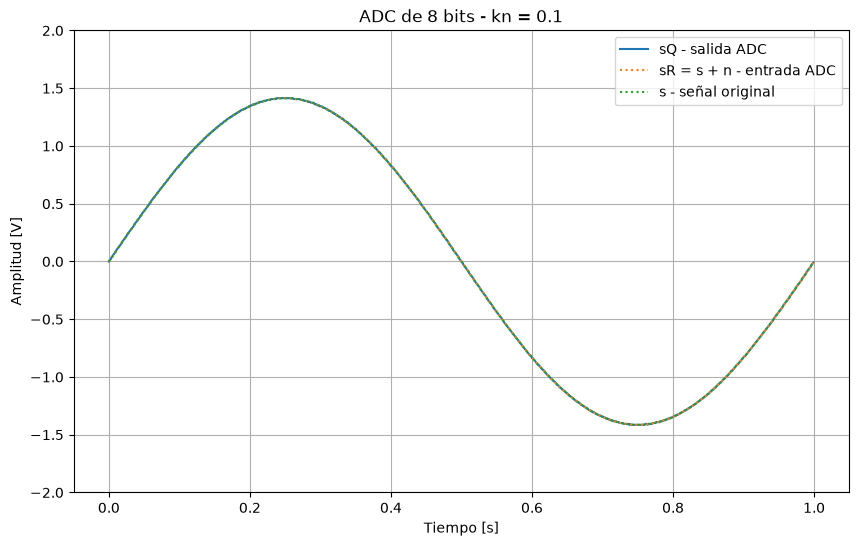

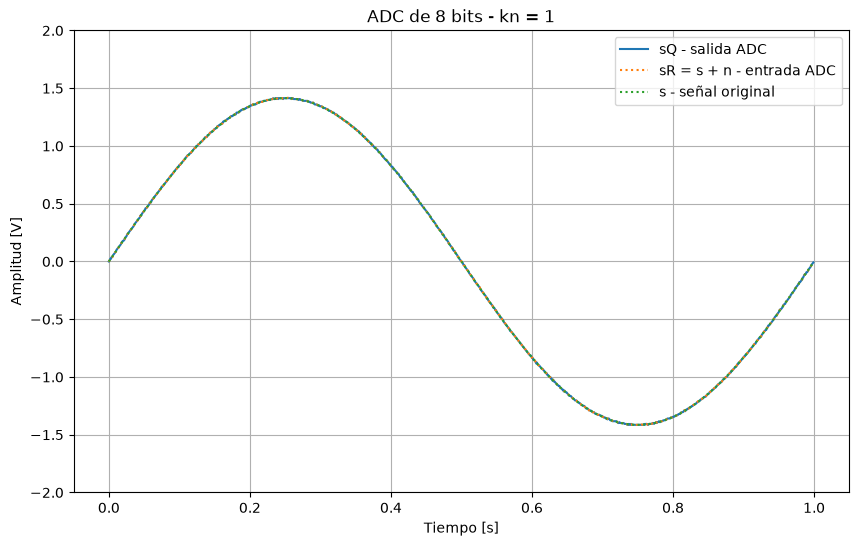

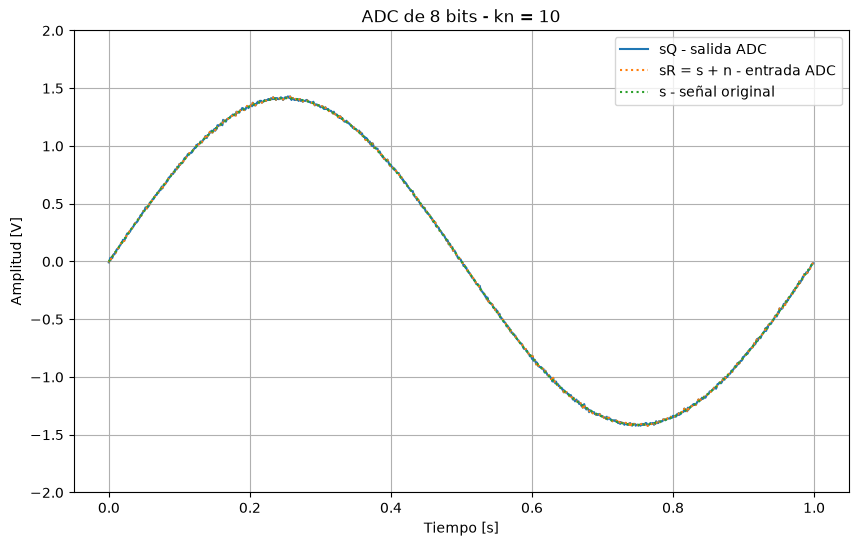

In [15]:
#%% Comparación para B = 8 bits y distintos valores de kn

B = 8
kn_valores = [0.1, 1, 10]

# Paso y potencia de cuantización
q = VF / (2**B)               # paso de cuantización
Pq = q**2 / 12                # potencia del ruido de cuantización

# Mismo ruido base para comparar los tres casos
ruido_base = np.random.normal(0, 1, N)

# Guardamos resultados para usarlos después en los espectros
resultados_8bits = {}

for kn in kn_valores:

    Pn = kn * Pq                  # potencia del ruido agregado
    sigma_n = np.sqrt(Pn)         # desvío estándar

    ruido = sigma_n * ruido_base  # ruido según el valor de kn

    sR = s + ruido                # entrada del ADC
    sQ = np.round(sR / q) * q     # salida cuantizada

    # Guardamos resultados
    resultados_8bits[kn] = {
        'sR': sR,
        'sQ': sQ,
        'Pn': Pn,
        'sigma': sigma_n
    }

    # Gráfico temporal
    plt.figure(figsize=(10,6))

    plt.plot(tt, sQ, label='sQ - salida ADC')
    plt.plot(tt, sR, ':', label='sR = s + n - entrada ADC')
    plt.plot(tt, s, ':', label='s - señal original')

    plt.title(f'ADC de 8 bits - kn = {kn}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.ylim(-2, 2)       # misma escala que con 4 bits
    plt.grid(True)
    plt.legend()

    plt.show()

En los gráficos de $8$ bits se ve que las tres señales quedan casi pegadas entre sí.

Esto pasa porque el paso de cuantización ahora es mucho más chico que en $4$ bits, entonces la señal se representa con más precisión.

Además, como el ruido agregado depende de la potencia de cuantización, también termina siendo más chico.

Por eso las diferencias entre los distintos valores de $k_n$ casi no se notan en el gráfico temporal.

En frecuencia se puede ver mejor la diferencia entre los distintos valores de $k_n$, ya que en el gráfico temporal las señales quedaron casi superpuestas.

Al usar $8$ bits el piso de cuantización baja bastante con respecto al caso de $4$ bits.

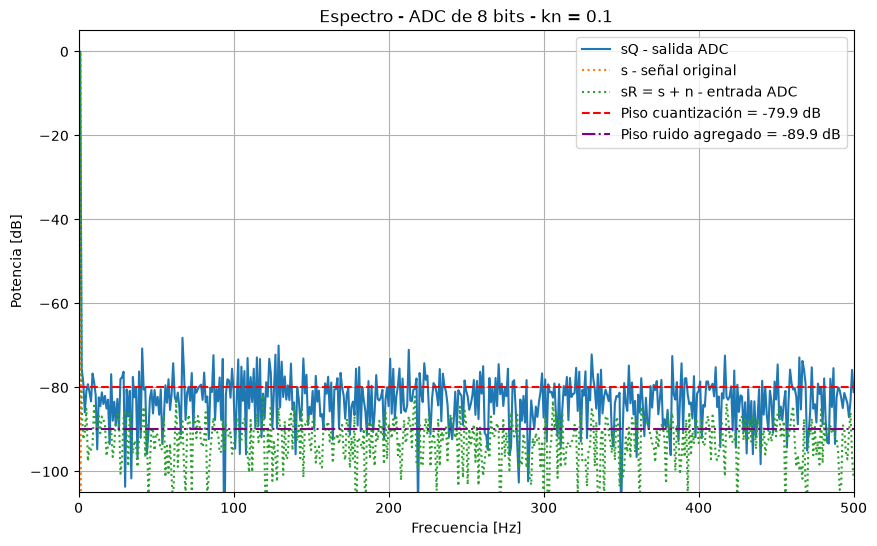

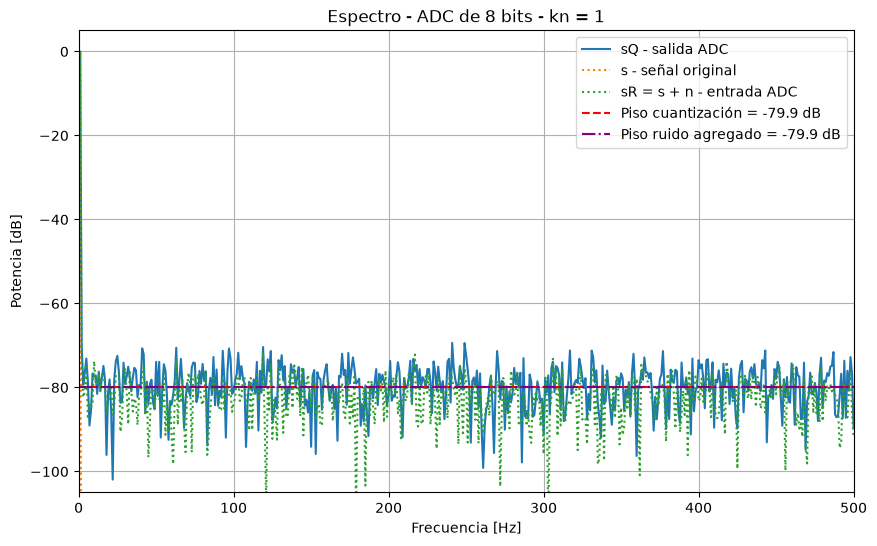

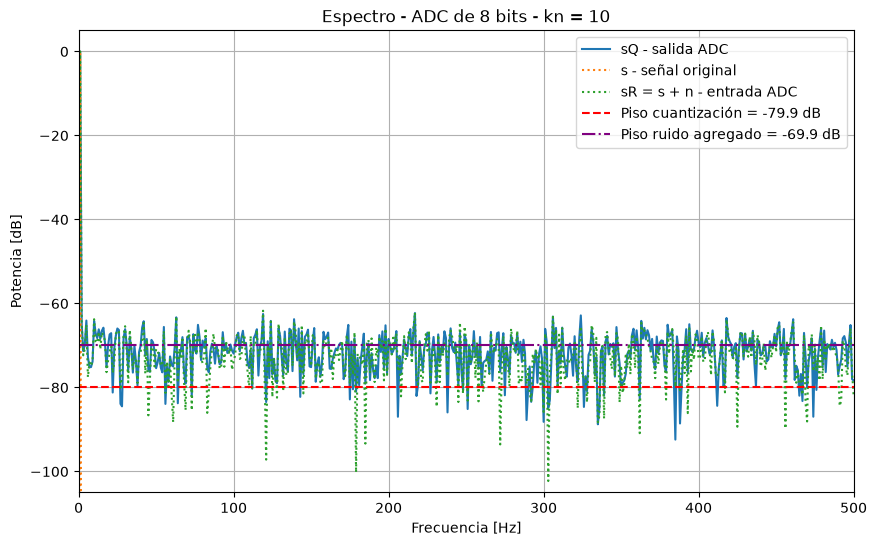

In [17]:
#%% Espectros para B = 8 bits y distintos valores de kn

# Piso teórico del ruido de cuantización
eta_q = 2 * Pq / fs
eta_q_dB = 10 * np.log10(eta_q)

for kn in kn_valores:

    # Recuperamos las señales generadas anteriormente
    sR = resultados_8bits[kn]['sR']     # entrada del ADC
    sQ = resultados_8bits[kn]['sQ']     # salida del ADC
    Pn = resultados_8bits[kn]['Pn']     # potencia del ruido agregado

    # FFT
    S = np.fft.rfft(s)                  # senoide original
    SR = np.fft.rfft(sR)                # señal con ruido
    SQ = np.fft.rfft(sQ)                # señal cuantizada

    # Eje de frecuencias
    ff = np.fft.rfftfreq(N, d=1/fs)

    # Potencia unilateral
    Ps = 2 * (np.abs(S)**2) / N**2
    PsR = 2 * (np.abs(SR)**2) / N**2
    PsQ = 2 * (np.abs(SQ)**2) / N**2

    # Valor pequeño para evitar log10(0)
    eps = 1e-20

    # Conversión a dB
    Ps_dB = 10 * np.log10(Ps + eps)
    PsR_dB = 10 * np.log10(PsR + eps)
    PsQ_dB = 10 * np.log10(PsQ + eps)

    # Piso teórico del ruido agregado
    eta_n = 2 * Pn / fs
    eta_n_dB = 10 * np.log10(eta_n)

    #%% Gráfico
    plt.figure(figsize=(10,6))

    plt.plot(ff, PsQ_dB, label='sQ - salida ADC')
    plt.plot(ff, Ps_dB, ':', label='s - señal original')
    plt.plot(ff, PsR_dB, ':', label='sR = s + n - entrada ADC')

    # Piso de cuantización
    plt.axhline(eta_q_dB,
                color='red',
                linestyle='--',
                label=f'Piso cuantización = {eta_q_dB:.1f} dB')

    # Piso del ruido agregado
    plt.axhline(eta_n_dB,
                color='purple',
                linestyle='-.',
                label=f'Piso ruido agregado = {eta_n_dB:.1f} dB')

    plt.title(f'Espectro - ADC de 8 bits - kn = {kn}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [dB]')
    plt.grid(True)
    plt.legend()

    plt.xlim(0, fs/2)
    plt.ylim(-105, 5)   # bajamos el límite para poder ver los pisos de 8 bits

    plt.show()

En los espectros de $8$ bits se vuelve a ver el mismo comportamiento al cambiar $k_n$, pero ahora los niveles de ruido están bastante más abajo que en $4$ bits.

También se nota que al aumentar de $4$ a $8$ bits el piso de cuantización baja bastante, por lo que la señal queda mejor representada.

Por último se repite la comparación utilizando $16$ bits.

En este caso el paso de cuantización es todavía más chico, por lo que se espera que las diferencias entre la señal original, la entrada y la salida del ADC sean casi imperceptibles en el gráfico temporal.

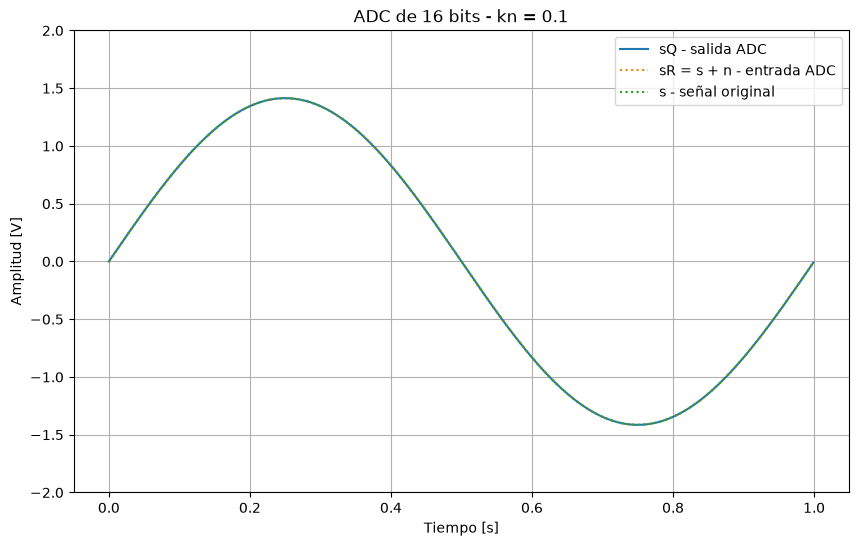

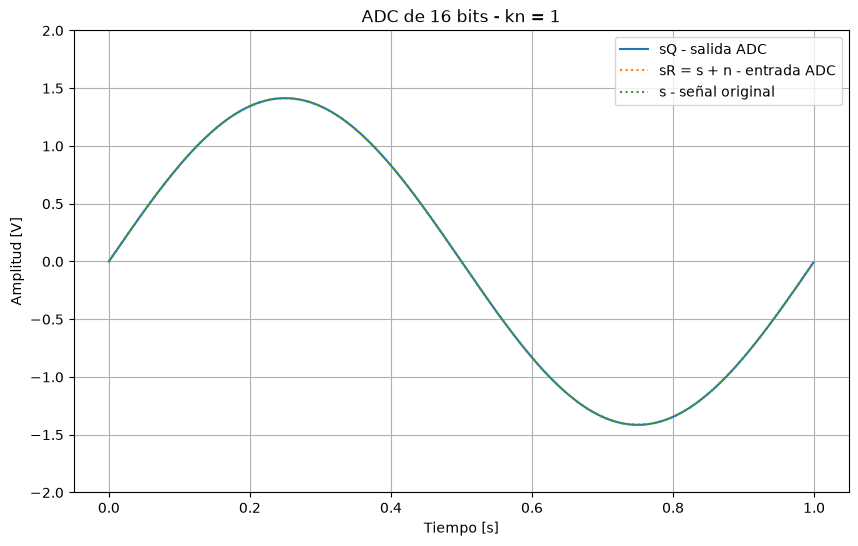

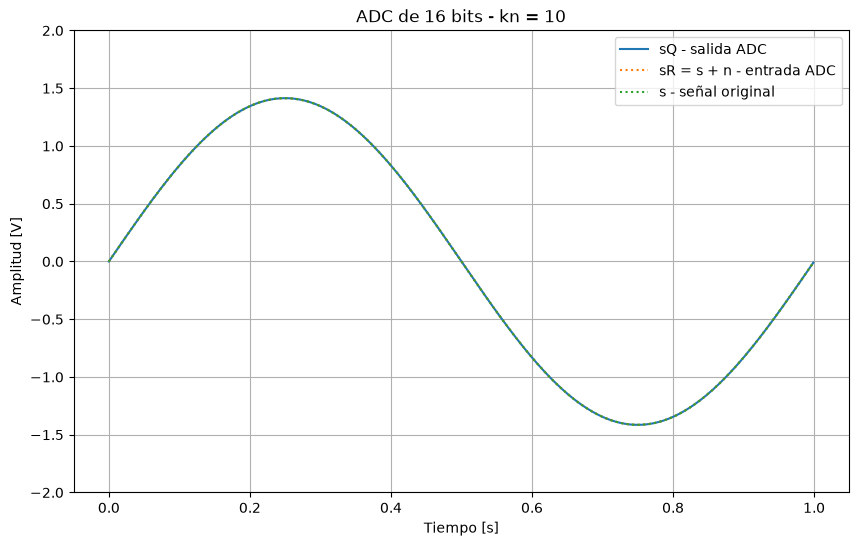

In [19]:
#%% Comparación para B = 16 bits y distintos valores de kn

B = 16
kn_valores = [0.1, 1, 10]

# Paso y potencia de cuantización
q = VF / (2**B)               # paso de cuantización
Pq = q**2 / 12                # potencia del ruido de cuantización

# Mismo ruido base para comparar los tres valores de kn
ruido_base = np.random.normal(0, 1, N)

# Guardamos los resultados para usarlos después
resultados_16bits = {}

for kn in kn_valores:

    Pn = kn * Pq                  # potencia del ruido agregado
    sigma_n = np.sqrt(Pn)         # desvío estándar del ruido

    ruido = sigma_n * ruido_base  # ruido según kn

    sR = s + ruido                # entrada del ADC
    sQ = np.round(sR / q) * q     # salida cuantizada

    # Guardamos los resultados
    resultados_16bits[kn] = {
        'sR': sR,
        'sQ': sQ,
        'Pn': Pn,
        'sigma': sigma_n
    }

    # Gráfico temporal
    plt.figure(figsize=(10,6))

    plt.plot(tt, sQ, label='sQ - salida ADC')
    plt.plot(tt, sR, ':', label='sR = s + n - entrada ADC')
    plt.plot(tt, s, ':', label='s - señal original')

    plt.title(f'ADC de 16 bits - kn = {kn}')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud [V]')
    plt.ylim(-2, 2)
    plt.grid(True)
    plt.legend()

    plt.show()

Imposibles de distinguir 

Voy a analizar el espectro para poder ver mejor las diferencias. Al tener un paso de cuantización mucho más chico, se espera que los pisos de ruido estén bastante más abajo que en los casos de 4 y 8 bits.  

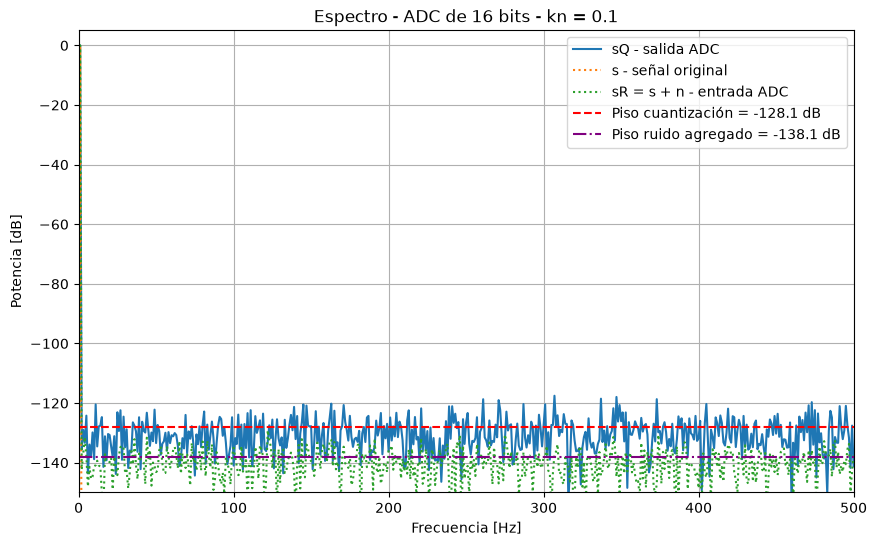

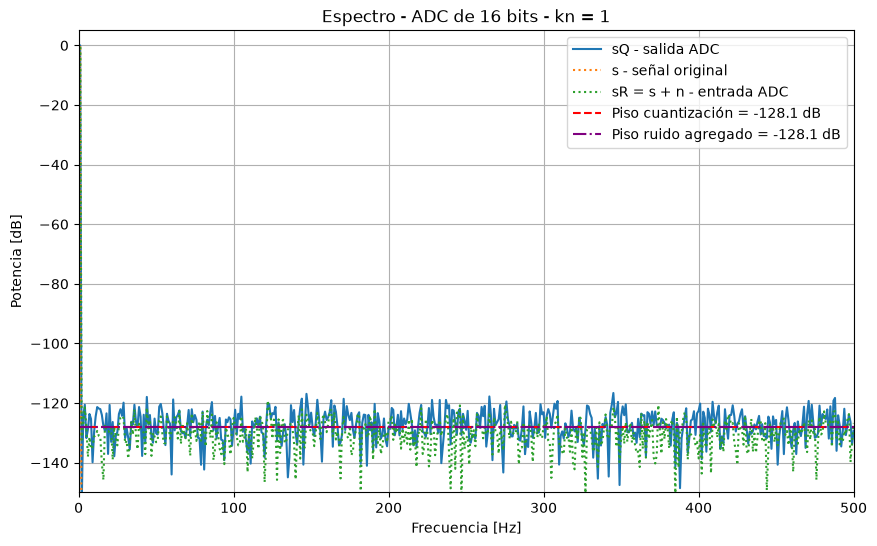

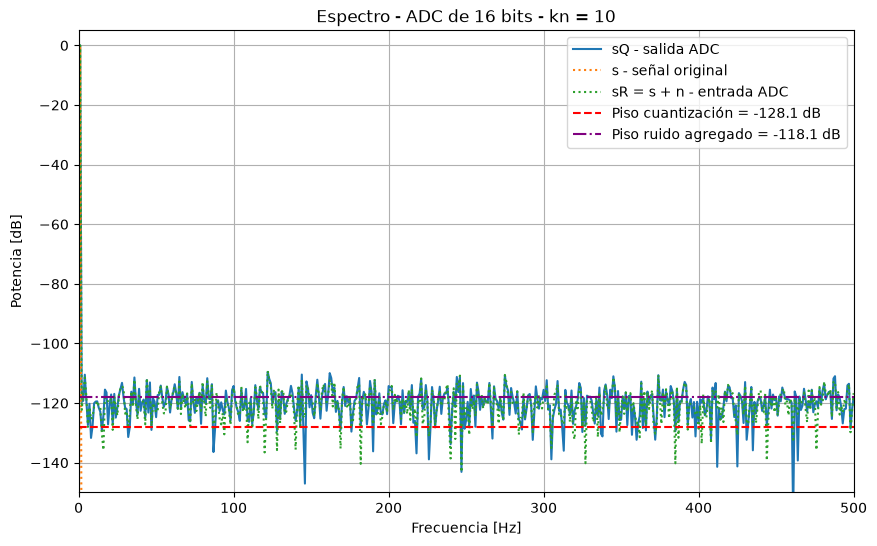

In [21]:
#%% Espectros para B = 16 bits y distintos valores de kn

# Piso teórico del ruido de cuantización
eta_q = 2 * Pq / fs
eta_q_dB = 10 * np.log10(eta_q)

for kn in kn_valores:

    # Recuperamos las señales generadas anteriormente
    sR = resultados_16bits[kn]['sR']    # entrada del ADC
    sQ = resultados_16bits[kn]['sQ']    # salida del ADC
    Pn = resultados_16bits[kn]['Pn']    # potencia del ruido agregado

    # FFT
    S = np.fft.rfft(s)                  # senoide original
    SR = np.fft.rfft(sR)                # señal con ruido
    SQ = np.fft.rfft(sQ)                # señal cuantizada

    # Eje de frecuencias
    ff = np.fft.rfftfreq(N, d=1/fs)

    # Potencia unilateral
    Ps = 2 * (np.abs(S)**2) / N**2
    PsR = 2 * (np.abs(SR)**2) / N**2
    PsQ = 2 * (np.abs(SQ)**2) / N**2

    # Valor pequeño para evitar log10(0)
    eps = 1e-20

    # Conversión a dB
    Ps_dB = 10 * np.log10(Ps + eps)
    PsR_dB = 10 * np.log10(PsR + eps)
    PsQ_dB = 10 * np.log10(PsQ + eps)

    # Piso teórico del ruido agregado
    eta_n = 2 * Pn / fs
    eta_n_dB = 10 * np.log10(eta_n)

    #%% Gráfico
    plt.figure(figsize=(10,6))

    plt.plot(ff, PsQ_dB, label='sQ - salida ADC')
    plt.plot(ff, Ps_dB, ':', label='s - señal original')
    plt.plot(ff, PsR_dB, ':', label='sR = s + n - entrada ADC')

    # Piso de cuantización
    plt.axhline(eta_q_dB,
                color='red',
                linestyle='--',
                label=f'Piso cuantización = {eta_q_dB:.1f} dB')

    # Piso del ruido agregado
    plt.axhline(eta_n_dB,
                color='purple',
                linestyle='-.',
                label=f'Piso ruido agregado = {eta_n_dB:.1f} dB')

    plt.title(f'Espectro - ADC de 16 bits - kn = {kn}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Potencia [dB]')
    plt.grid(True)
    plt.legend()

    plt.xlim(0, fs/2)
    plt.ylim(-150, 5)     # como los pisos son  mucho mas bajos cambio la escala del zoom 

    plt.show()

En los espectros de $16$ bits se mantiene el mismo comportamiento visto antes al cambiar $k_n$, pero los pisos de ruido aparecen mucho más abajo.

El piso de cuantización queda cerca de $-128.1\,\text{dB}$, por lo que el efecto de la cuantización es mucho menor que en $4$ y $8$ bits.

## Conclusiones:
### Punto a:
En este punto se pudo ver cómo una señal senoidal cambia al agregarle ruido y después pasarla por un ADC de $4$ bits.

En el gráfico temporal se observa que la señal cuantizada sigue bastante bien a la entrada, aunque aparecen pequeños escalones por el paso de cuantización.

En frecuencia se pudo distinguir el pico de la senoide y el piso de ruido, y en el histograma se vio que el error de cuantización queda aproximadamente entre $-q/2$ y $+q/2$.

En general, el resultado coincide con lo esperado para este caso.
### Punto b:
En este punto se pudo ver cómo cambian los resultados al modificar la cantidad de bits y el valor de $k_n$.

Cuando se aumentan los bits, el paso de cuantización se hace más chico y por eso también disminuye el ruido de cuantización.

Esto se notó bastante al comparar $4$, $8$ y $16$ bits, ya que las señales se fueron viendo cada vez más parecidas entre sí y los pisos de ruido bajaron mucho.

Por otro lado, al aumentar $k_n$ aumenta el ruido agregado, por lo que su piso de ruido sube.

En general, se vio que usar más bits mejora bastante la representación de la señal, mientras que un valor mayor de $k_n$ hace que el ruido tenga más efecto.